In [2]:
"""
This notebook implements the Valley Bottom Extraction tool to identify maximum riparian extent along the Cheyenne River, SD
The output polygon of riparian extents will serve as the study region for our cottonwood analysis
"""




import os, sys
# Must be set before importing pyproj/geopandas/pynhd
os.environ['PROJ_DATA'] = os.path.join(sys.prefix, 'share', 'proj')
os.environ['PROJ_LIB'] = os.path.join(sys.prefix, 'share', 'proj')

import folium
from pynhd import NLDI

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

print("Ready to go !")

Ready to go !


<Axes: >

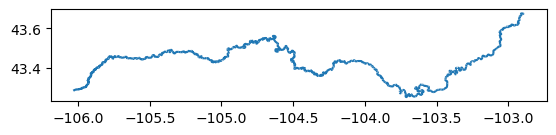

In [3]:
# --- Access NHDPlus Flowlines and USGS gauge data ---

nldi = NLDI()
station_id = "06403700" # Cheyenne River at Red Shirt USGS gauge site
station = nldi.getfeature_byid("nwissite", f"USGS-{station_id}").to_crs(4326)
basin = nldi.get_basins(station_id) # get the basin associated

# --- Find all other stations upstream
st_all = nldi.navigate_byid(
    fsource="nwissite",
    fid=f"USGS-{station_id}",
    navigation="upstreamTributaries",
    source="nwissite",
    distance=1000, # km (so 1k gets everything in the basin)
)

# --- Gather the flowlines (main and tribs)
flw_main_us = nldi.navigate_byid(
    fsource="nwissite",
    fid=f"USGS-{station_id}",
    navigation="upstreamMain",
    source="flowlines",
    distance=1000,
)

flw_main_ds = nldi.navigate_byid(
    fsource="nwissite",
    fid=f"USGS-{station_id}",
    navigation="downstreamMain",
    source="flowlines",
    distance=1000,
)

flw_trib = nldi.navigate_byid(
    fsource="nwissite",
    fid=f"USGS-{station_id}",
    navigation="upstreamTributaries",
    source="flowlines",
    distance=1000,
)

flw_main_us.plot()

In [4]:
# make a folium map
# Center the map roughly over the basin
center = [basin.geometry.iloc[0].centroid.y, basin.geometry.iloc[0].centroid.x]
m = folium.Map(location=center, zoom_start=9)

# Add layers
folium.GeoJson(
    basin, name="Stream Basin",
    style_function=lambda x: {
        "color": "orange",
        "weight": 2,
        "fillOpacity": 0.1
    },).add_to(m)

folium.GeoJson(
    flw_main_us, name="Mainstem Flowline (upstream)",
    style_function=lambda x: {"color": "blue", "weight": 3},
).add_to(m)

folium.GeoJson(
    flw_main_ds, name="Mainstem Flowline (downstream)",
    style_function=lambda x: {"color": "blue", "weight": 3},
).add_to(m)

folium.GeoJson(
    flw_trib, name="Tributary Flowlines",
    style_function=lambda x: {"color": "cyan", "weight": 1},
).add_to(m)

# Upstream USGS stations
for _, row in st_all.iterrows():
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=3,
        color="yellow",
        fill=True,
        fill_opacity=0.8,
        popup=f"Station: {row['identifier']}",
    ).add_to(m)

# The main station
folium.Marker(
    location=[station.geometry.y, station.geometry.x],
    popup=f"Main Gauge: {station_id}",
    icon=folium.Icon(color="red", icon="tint", prefix="fa"),
).add_to(m)

folium.LayerControl().add_to(m)
m

ValueError: Location should consist of two numerical values, but 0    43.672406
dtype: float64 of type <class 'pandas.Series'> is not convertible to float.